1. Vytvořte tabulku níže pomocí Pythonu a propojte je pomocí cizích klíčů

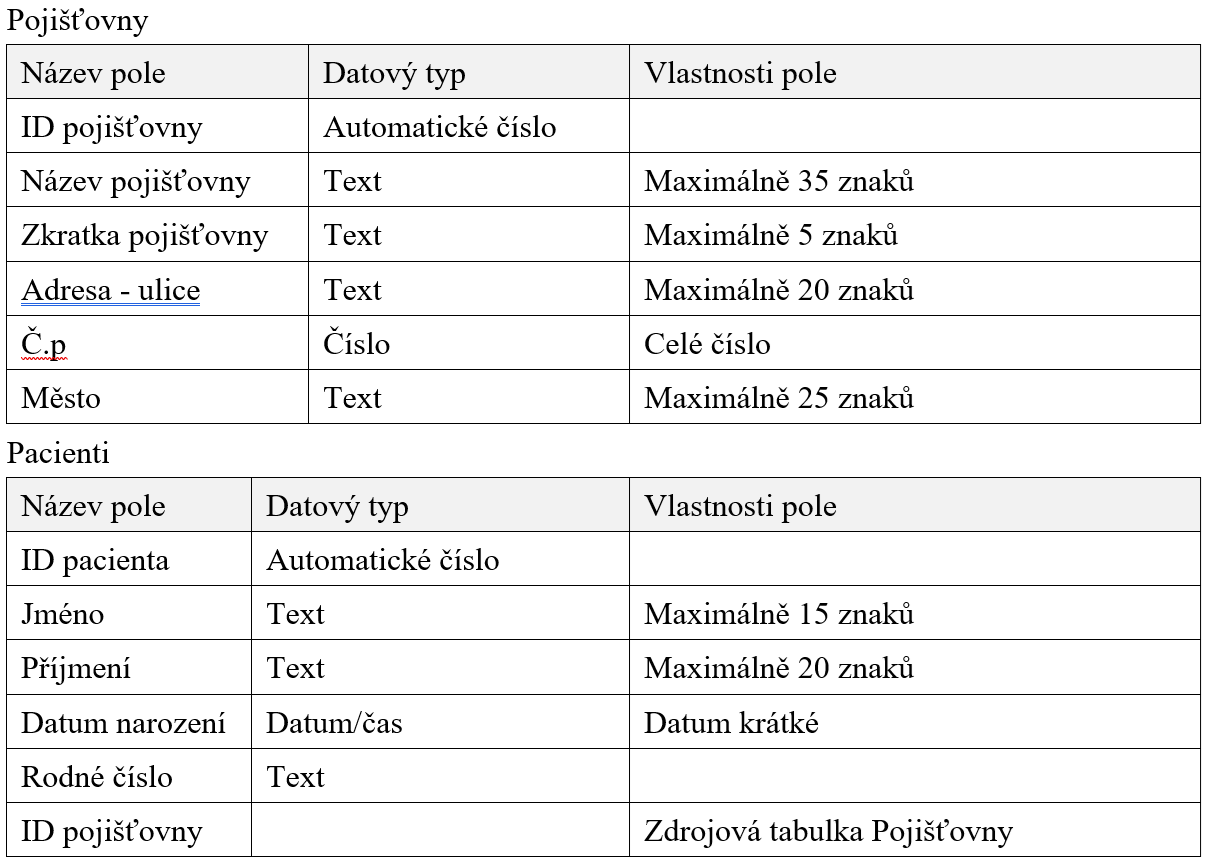

In [25]:
import mysql.connector
from pripojeni import *

mydb = mysql.connector.connect(
    host=HOST,
    user=USER,
    password=PASSWORD,
    database=DATABASE
)

mycursor = mydb.cursor()

# vytvoření tabulky pojistovny
mycursor.execute("""
CREATE TABLE pojistovny6(
    id_pojistovny INT NOT NULL PRIMARY KEY,
    nazev_pojistovny VARCHAR(35),
    zkratka_pojistovny VARCHAR(5),
    adresa VARCHAR(20),
    cislo_popisne INT,
    mesto VARCHAR(25)
)
""")

mydb.commit()

# vytvoření tabulky pacienti
mycursor.execute("""
CREATE TABLE pacienti6(
    id_pacienta INT NOT NULL PRIMARY KEY,
    jmeno VARCHAR(15) NOT NULL,
    prijmeni VARCHAR(20) NOT NULL,
    datum_narozeni VARCHAR(10) NOT NULL,
    rodne_cislo VARCHAR(15) NOT NULL,
    id_pojistovny INT
)
""")

mydb.commit()

mycursor.close()
mydb.close()

2. Vložte do těchto tabulek tři záznamy pomocí příkazu insert

In [ ]:
import mysql.connector
from pripojeni import *

mydb = mysql.connector.connect(
    host=HOST,
    user=USER,
    password=PASSWORD,
    database=DATABASE
)

mycursor = mydb.cursor()


mycursor.execute("""
INSERT INTO pojistovny6
(id_pojistovny, nazev_pojistovny, zkratka_pojistovny, adresa, cislo_popisne, mesto) VALUES
(100, 'TheGoats', 'goats', 'U Potoka', 249284, 'Kladno'),
(111, 'TheNoobs', 'noobs', 'U Ptáka', 388382, 'Praha'),
(122, 'OndrejCerny', 'inby', 'U Batmana', 448833, 'Most')
""")


mycursor.execute("""
INSERT INTO pacienti6
(id_pacienta, jmeno, prijmeni, datum_narozeni, rodne_cislo, id_pojistovny) VALUES
(99, 'ondrej', 'cerny', '2007', '249284', 1999),
(88, 'robert', 'hancikovsky', '2008', '388382', 2999),
(77, 'tomas', 'inby', '1997', '448833', 3999)
""")

mydb.commit()

mycursor.close()
mydb.close()

3. Vypište všechny informace o prvním pacientovi

In [ ]:
mycursor.execute("""SELECT id_pacienta, jmeno, prijmeni, datum_narozeni, rodne_cislo, id_pojistovny FROM pacienti6 LIMIT 1
""") # Tento příkaz vypíše počet sedadel a maximální rychlost, ale pouze jeden záznam.

myresult = mycursor.fetchall()

for pocet_sedadel, max_rychlost in myresult:
    print(f"""
    Auto má {pocet_sedadel} sedadel a maximální rychlost {max_rychlost} km/h.
    """)


    Jméno: John
    Příjmení: Doe
    Datum narození: 1990-01-15
    Rodné číslo: 90011512345
    ID pojišťovny: 1


4. Vypište všechny informace pacientech a také všechny infromace o jeho pojišťovně pomocí Joinu

In [ ]:
# TODO
import mysql.connector


Pacient John Doe, s rodným číslem: 90011512345 s datem narození 1990-01-15, pojištěný v pojišťovně Všeobecná zdravotní pojišťovna (VZP) se sídlem v městě: Prague, Main Street 123
Pacient Alice Smith, s rodným číslem: 85052045678 s datem narození 1985-05-20, pojištěný v pojišťovně Allianz (ALZ) se sídlem v městě: Berlin, Highway Avenue 456
Pacient Bob Johnson, s rodným číslem: 88111078901 s datem narození 1988-11-10, pojištěný v pojišťovně AXA (AXA) se sídlem v městě: Paris, Broadway 789


5. Zjistěte průměrný věk pacientů